Using Device: cpu

TASK 2018
Epoch 0 Loss: 1.020333
Epoch 50 Loss: 0.022444
Epoch 100 Loss: 0.009279
Epoch 150 Loss: 0.006072
Epoch 200 Loss: 0.005352
Epoch 250 Loss: 0.005128
RMSE : 0.0594
MAE  : 0.0341
R²   : 0.9366

TASK 2019
Epoch 0 Loss: 1.370902
Epoch 50 Loss: 0.01761
Epoch 100 Loss: 0.009907
Epoch 150 Loss: 0.008734
Epoch 200 Loss: 0.008287
Epoch 250 Loss: 0.008029
RMSE : 0.0674
MAE  : 0.0444
R²   : 0.9339

TASK 2020
Epoch 0 Loss: 1.265326
Epoch 50 Loss: 0.008273
Epoch 100 Loss: 0.005379
Epoch 150 Loss: 0.00452
Epoch 200 Loss: 0.0041
Epoch 250 Loss: 0.003872
RMSE : 0.0517
MAE  : 0.0372
R²   : 0.957

TASK 2021
Epoch 0 Loss: 1.502995
Epoch 50 Loss: 0.02331
Epoch 100 Loss: 0.011907
Epoch 150 Loss: 0.00945
Epoch 200 Loss: 0.008371
Epoch 250 Loss: 0.007983
RMSE : 0.0598
MAE  : 0.0361
R²   : 0.857

TASK 2022
Epoch 0 Loss: 0.853568
Epoch 50 Loss: 0.015344
Epoch 100 Loss: 0.008633
Epoch 150 Loss: 0.006916
Epoch 200 Loss: 0.006338
Epoch 250 Loss: 0.006069
RMSE : 0.0687
MAE  : 0.0504
R²  

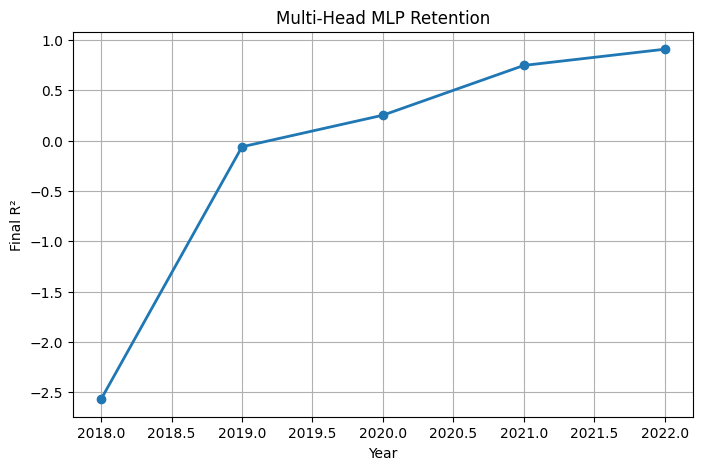

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =====================================
# LOAD DATA
# =====================================

df2018 = pd.read_excel("../data/2018.xlsx")
df2019 = pd.read_excel("../data/2019.xlsx")
df2020 = pd.read_excel("../data/2020.xlsx")
df2021 = pd.read_excel("../data/2021.xlsx")
df2022 = pd.read_excel("../data/2022.xlsx")

# =====================================
# PREPROCESS
# =====================================

def preprocess(df):

    df = df[['time','sst']].copy()

    df['time'] = pd.to_datetime(df['time'])

    df['month'] = df['time'].dt.month
    df['day'] = df['time'].dt.day
    df['hour'] = df['time'].dt.hour
    df['dayofyear'] = df['time'].dt.dayofyear

    df['sst_lag1'] = df['sst'].shift(1)
    df['sst_lag8'] = df['sst'].shift(8)
    df['sst_lag24'] = df['sst'].shift(24)

    df.dropna(inplace=True)

    return df

df2018 = preprocess(df2018)
df2019 = preprocess(df2019)
df2020 = preprocess(df2020)
df2021 = preprocess(df2021)
df2022 = preprocess(df2022)

tasks = [
    df2018,
    df2019,
    df2020,
    df2021,
    df2022
]

features = [
    'month',
    'day',
    'hour',
    'dayofyear',
    'sst_lag1',
    'sst_lag8',
    'sst_lag24'
]

target = 'sst'
# =====================================
# DEVICE
# =====================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

# =====================================
# MODEL
# =====================================

class MultiHeadMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.shared = nn.Sequential(

            nn.Linear(7,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU()

        )

        self.heads = nn.ModuleList([

            nn.Linear(64,1),  # 2018
            nn.Linear(64,1),  # 2019
            nn.Linear(64,1),  # 2020
            nn.Linear(64,1),  # 2021
            nn.Linear(64,1)   # 2022

        ])

    def forward(self,x,task_id):

        features = self.shared(x)

        return self.heads[task_id](features)

# =====================================
# MODEL SETUP
# =====================================

model = MultiHeadMLP().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 300

# =====================================
# STORAGE
# =====================================

rmses = []
maes = []
r2s = []

test_sets = []

# =====================================
# TASK LOOP
# =====================================

for task_id, task in enumerate(tasks):

    year = 2018 + task_id

    print("\n===================================")
    print("TASK", year)
    print("===================================")

    X = task[features].values
    y = task[target].values

    split = int(len(X)*0.8)

    X_train = X[:split]
    X_test  = X[split:]

    y_train = y[:split]
    y_test  = y[split:]

    # ----------------------------
    # Scale X
    # ----------------------------

    x_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_test  = x_scaler.transform(X_test)

    # ----------------------------
    # Scale y
    # ----------------------------

    y_scaler = StandardScaler()

    y_train_scaled = y_scaler.fit_transform(
        y_train.reshape(-1,1)
    )

    # ----------------------------
    # Tensor
    # ----------------------------

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    ).to(device)

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    y_train_scaled = torch.tensor(
        y_train_scaled,
        dtype=torch.float32
    ).to(device)

    # ----------------------------
    # Save for retention
    # ----------------------------

    test_sets.append({

        "year": year,

        "head": task_id,

        "X_test": X_test.cpu().numpy(),

        "y_test": y_test,

        "y_scaler": y_scaler

    })

    # ----------------------------
    # Train
    # ----------------------------

    start = time.time()

    model.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        preds = model(
            X_train,
            task_id
        )

        loss = criterion(
            preds,
            y_train_scaled
        )

        loss.backward()

        optimizer.step()

        if epoch % 50 == 0:

            print(
                f"Epoch {epoch} Loss:",
                round(loss.item(),6)
            )

    # ----------------------------
    # Evaluate Current Task
    # ----------------------------

    model.eval()

    with torch.no_grad():

        preds_scaled = model(
            X_test,
            task_id
        ).cpu().numpy()

    preds = y_scaler.inverse_transform(
        preds_scaled
    )

    y_true = y_test.reshape(-1,1)

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            preds
        )
    )

    mae = mean_absolute_error(
        y_true,
        preds
    )

    r2 = r2_score(
        y_true,
        preds
    )

    rmses.append(rmse)
    maes.append(mae)
    r2s.append(r2)

    print("RMSE :", round(rmse,4))
    print("MAE  :", round(mae,4))
    print("R²   :", round(r2,4))

# =====================================
# FINAL RESULTS
# =====================================

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print("Average RMSE:", round(np.mean(rmses),4))
print("Average MAE :", round(np.mean(maes),4))
print("Average R²  :", round(np.mean(r2s),4))

# =====================================
# RETENTION ANALYSIS
# =====================================

print("\n===================================")
print("RETENTION ANALYSIS")
print("===================================")

retention_r2 = []

years = []

for item in test_sets:

    year = item["year"]

    head = item["head"]

    years.append(year)

    X_test = torch.tensor(
        item["X_test"],
        dtype=torch.float32
    ).to(device)

    y_test = item["y_test"]

    y_scaler = item["y_scaler"]

    with torch.no_grad():

        preds_scaled = model(
            X_test,
            head
        ).cpu().numpy()

    preds = y_scaler.inverse_transform(
        preds_scaled
    )

    y_true = y_test.reshape(-1,1)

    r2 = r2_score(
        y_true,
        preds
    )

    retention_r2.append(r2)

    print(
        f"Year {year} -> R² = {round(r2,4)}"
    )

# =====================================
# PLOT
# =====================================

plt.figure(figsize=(8,5))

plt.plot(
    years,
    retention_r2,
    marker="o",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Final R²")
plt.title("Multi-Head MLP Retention")
plt.grid(True)

plt.show()